In [1]:
import torch
import src.custom_fastkan
import importlib
importlib.reload(src.custom_fastkan)
from src.custom_fastkan import FastKAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
csv_path = 'data/jena_climate_2009_2016.csv'
df = pd.read_csv(csv_path)
df = df[5::6]
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

print(f"Dataset shape: {df.shape}")
print(f"Date range: {date_time.min()} to {date_time.max()}")

Dataset shape: (70091, 14)
Date range: 2009-01-01 01:00:00 to 2016-12-31 23:10:00


In [3]:
target_features = ['T (degC)']
input_features = df.columns.tolist()
print(f"Target: {target_features}, Inputs: {len(input_features)} features")

Target: ['T (degC)'], Inputs: 14 features


In [4]:
data = df.values
mean = data.mean(axis=0)
std = data.std(axis=0)
data_norm = (data - mean) / std

HISTORY_SIZE = 12
STEP = 1
TARGET_SIZE = 6

target_indices = [df.columns.tolist().index(feat) for feat in target_features]
print(f"{HISTORY_SIZE}h history → {TARGET_SIZE}h forecast, {len(target_features)} variables = {len(target_features) * TARGET_SIZE} outputs")

12h history → 6h forecast, 1 variables = 6 outputs


In [5]:
# Create multi-step, multi-output sequences
def multivariate_data(dataset, target_indices, start_index, end_index, 
                      history_size, target_size, step):
    data = []
    labels = []
    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index, step):
        indices = range(i - history_size, i)
        data.append(dataset[indices])
        target_data = []
        for target_idx in target_indices:
            target_data.append(dataset[i:i + target_size, target_idx])
        labels.append(np.concatenate(target_data))

    return np.array(data), np.array(labels)

X_train, y_train = multivariate_data(
    data_norm, target_indices, 0, int(0.7 * len(data_norm)),
    HISTORY_SIZE, TARGET_SIZE, STEP
)

X_val, y_val = multivariate_data(
    data_norm, target_indices, int(0.7 * len(data_norm)), int(0.85 * len(data_norm)),
    HISTORY_SIZE, TARGET_SIZE, STEP
)

X_test, y_test = multivariate_data(
    data_norm, target_indices, int(0.85 * len(data_norm)), None,
    HISTORY_SIZE, TARGET_SIZE, STEP
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (49051, 12, 14), Val: (10502, 12, 14), Test: (10496, 12, 14)


In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

input_dim = X_train_flat.shape[1]
output_dim = y_train.shape[1]
print(f"Model: {input_dim} inputs → {output_dim} outputs")

Model: 168 inputs → 6 outputs


In [7]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

kan_model = FastKAN(
    [input_dim, 16, output_dim], 
    grid_min=-2.0, 
    grid_max=2.0, 
    num_grids=8,
    use_base_update=False,
    use_layernorm=False
).to(device)

kan_optimizer = torch.optim.Adam(kan_model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()
print(f"KAN: [{input_dim}, 16, {output_dim}] - {sum(p.numel() for p in kan_model.parameters()):,} params")

KAN: [168, 16, 6] - 22,288 params


In [8]:
print("Training KAN Model...")

kan_train_losses = []
kan_val_losses = []

batch_size = 256
num_epochs = 50

best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_kan_state = kan_model.state_dict().copy()

for epoch in range(num_epochs):
    kan_model.train()
    epoch_loss = 0
    num_batches = 0
    
    indices = torch.randperm(len(X_train_tensor))
    for i in range(0, len(X_train_tensor), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_tensor[batch_idx]
        y_batch = y_train_tensor[batch_idx]
        
        kan_optimizer.zero_grad()
        pred = kan_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        kan_optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
    avg_train_loss = epoch_loss / num_batches
    
    kan_model.eval()
    with torch.no_grad():
        val_pred = kan_model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor).item()
    
    kan_train_losses.append(avg_train_loss)
    kan_val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {avg_train_loss:.6f}, Val MSE: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_kan_state = kan_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

kan_model.load_state_dict(best_kan_state)
kan_model.eval()
with torch.no_grad():
    kan_test_pred = kan_model(X_test_tensor)
    kan_test_loss = criterion(kan_test_pred, y_test_tensor).item()
print(f"KAN Test MSE: {kan_test_loss:.6f}")

Training KAN Model...
Epoch 5/50 - Train MSE: 0.058940, Val MSE: 0.066576
Epoch 10/50 - Train MSE: 0.048514, Val MSE: 0.060912
Epoch 15/50 - Train MSE: 0.045576, Val MSE: 0.057402
Epoch 20/50 - Train MSE: 0.043105, Val MSE: 0.057267
Epoch 25/50 - Train MSE: 0.042281, Val MSE: 0.058148
Epoch 30/50 - Train MSE: 0.041638, Val MSE: 0.053609
Epoch 35/50 - Train MSE: 0.040467, Val MSE: 0.054387
Epoch 40/50 - Train MSE: 0.040418, Val MSE: 0.055243
Epoch 45/50 - Train MSE: 0.039262, Val MSE: 0.054583
Early stopping at epoch 49
KAN Test MSE: 0.049989


In [9]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(MLP, self).__init__()
        layers = []
        curr_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, output_dim))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

mlp_model = MLP(input_dim=input_dim, hidden_dims=[32], output_dim=output_dim).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.0001)
print(f"MLP: [{input_dim}, 32, {output_dim}] - {sum(p.numel() for p in mlp_model.parameters()):,} params")

MLP: [168, 32, 6] - 5,670 params


In [10]:
print("Training MLP Model...")

mlp_train_losses = []
mlp_val_losses = []

best_val_loss = float('inf')
patience_counter = 0
best_mlp_state = mlp_model.state_dict().copy()

for epoch in range(num_epochs):
    mlp_model.train()
    epoch_loss = 0
    num_batches = 0
    
    indices = torch.randperm(len(X_train_tensor))
    for i in range(0, len(X_train_tensor), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_tensor[batch_idx]
        y_batch = y_train_tensor[batch_idx]
        
        mlp_optimizer.zero_grad()
        pred = mlp_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), max_norm=1.0)
        mlp_optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
    avg_train_loss = epoch_loss / num_batches
    
    mlp_model.eval()
    with torch.no_grad():
        val_pred = mlp_model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor).item()
    
    mlp_train_losses.append(avg_train_loss)
    mlp_val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {avg_train_loss:.6f}, Val MSE: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_mlp_state = mlp_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

mlp_model.load_state_dict(best_mlp_state)
mlp_model.eval()
with torch.no_grad():
    mlp_test_pred = mlp_model(X_test_tensor)
    mlp_test_loss = criterion(mlp_test_pred, y_test_tensor).item()
print(f"MLP Test MSE: {mlp_test_loss:.6f}")

Training MLP Model...
Epoch 5/50 - Train MSE: 0.070379, Val MSE: 19.035858
Epoch 10/50 - Train MSE: 0.059403, Val MSE: 39.171619
Early stopping at epoch 11
MLP Test MSE: 0.050451


In [11]:
kan_model.eval()
mlp_model.eval()
with torch.no_grad():
    kan_pred = kan_model(X_test_tensor).cpu().numpy()
    mlp_pred = mlp_model(X_test_tensor).cpu().numpy()
y_true = y_test

# Compute metrics
kan_mse = mean_squared_error(y_true, kan_pred)
mlp_mse = mean_squared_error(y_true, mlp_pred)
kan_rmse = np.sqrt(kan_mse)
mlp_rmse = np.sqrt(mlp_mse)
kan_r2 = r2_score(y_true.flatten(), kan_pred.flatten())
mlp_r2 = r2_score(y_true.flatten(), mlp_pred.flatten())

print(f"\n{'='*80}")
print(f"Model Metrics for {target_features[0]}")
print(f"{'='*80}")
print(f"KAN: [{input_dim}, 16, {output_dim}] - MSE: {kan_mse:.6f}, RMSE: {kan_rmse:.6f}, R2: {kan_r2:.6f}")
print(f"MLP: [{input_dim}, 32, {output_dim}] - MSE: {mlp_mse:.6f}, RMSE: {mlp_rmse:.6f}, R2: {mlp_r2:.6f}")


Model Metrics for T (degC)
KAN: [168, 16, 6] - MSE: 0.049989, RMSE: 0.223582, R2: 0.941424
MLP: [168, 32, 6] - MSE: 0.050451, RMSE: 0.224613, R2: 0.940883


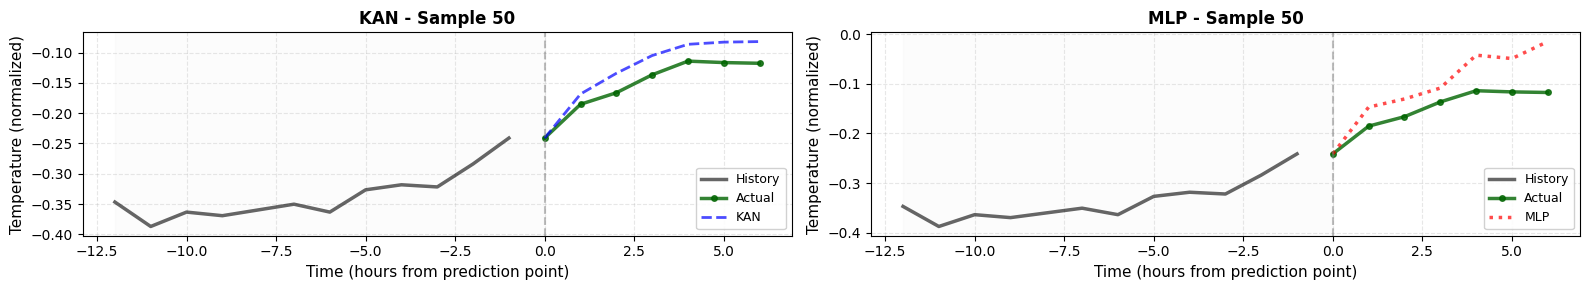

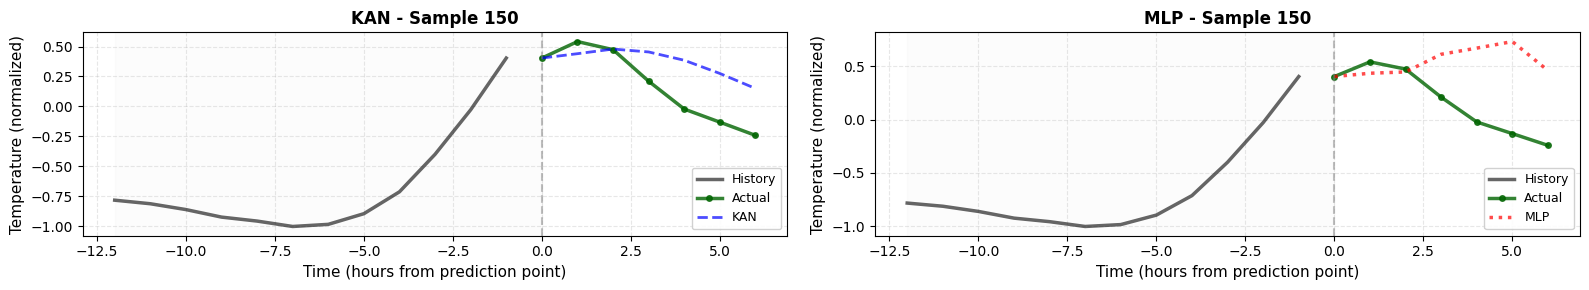

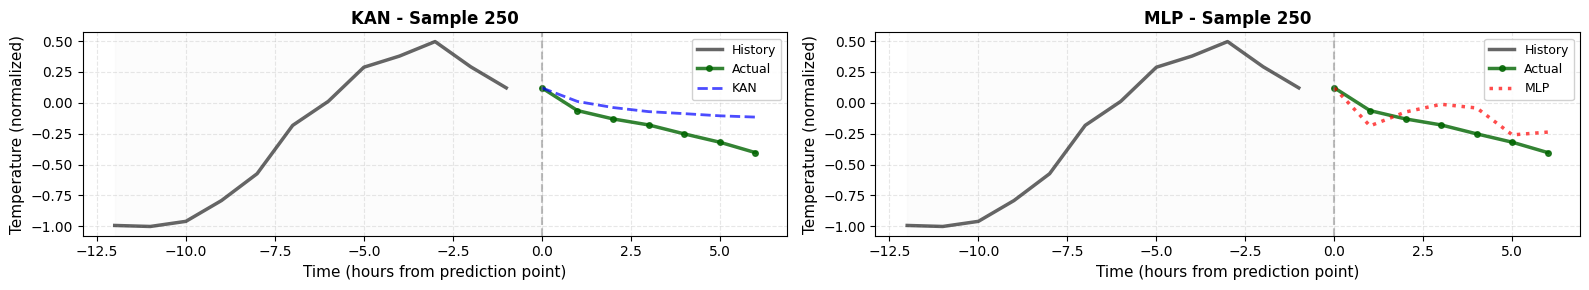

In [12]:
def plot_combined_comparison(sample_idx):
    fig, axes = plt.subplots(1, 2, figsize=(16, 3))
    history_data = X_test[sample_idx]
    history_time = np.arange(-HISTORY_SIZE, 0)
    prediction_time = np.arange(0, TARGET_SIZE + 1)
    
    target_col_idx = df.columns.tolist().index('T (degC)')
    history_values = history_data[:, target_col_idx]
    
    # Extract temperature predictions and actual (first TARGET_SIZE values)
    temp_kan = kan_pred[sample_idx, :TARGET_SIZE]
    temp_mlp = mlp_pred[sample_idx, :TARGET_SIZE]
    temp_actual = y_true[sample_idx, :TARGET_SIZE]
    
    # Add last history point to connect the lines
    last_history = history_values[-1]
    temp_actual_connected = np.concatenate([[last_history], temp_actual])
    temp_kan_connected = np.concatenate([[last_history], temp_kan])
    temp_mlp_connected = np.concatenate([[last_history], temp_mlp])
    
    # KAN plot (left)
    axes[0].plot(history_time, history_values, '-', color='black', linewidth=2.5, alpha=0.6, label='History')
    axes[0].plot(prediction_time, temp_actual_connected, 'o-', color='darkgreen', linewidth=2.5, markersize=4, alpha=0.8, label='Actual')
    axes[0].plot(prediction_time, temp_kan_connected, '--', color='blue', linewidth=2, markersize=3, alpha=0.7, label='KAN')
    axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    axes[0].set_xlabel('Time (hours from prediction point)', fontsize=11)
    axes[0].set_ylabel('Temperature (normalized)', fontsize=11)
    axes[0].set_title(f'KAN - Sample {sample_idx}', fontsize=12, fontweight='bold')
    axes[0].legend(loc='best', fontsize=9, framealpha=0.9)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].axvspan(-HISTORY_SIZE, 0, alpha=0.02, color='gray')
    
    # MLP plot (right)
    axes[1].plot(history_time, history_values, '-', color='black', linewidth=2.5, alpha=0.6, label='History')
    axes[1].plot(prediction_time, temp_actual_connected, 'o-', color='darkgreen', linewidth=2.5, markersize=4, alpha=0.8, label='Actual')
    axes[1].plot(prediction_time, temp_mlp_connected, ':', color='red', linewidth=2.5, markersize=3, alpha=0.7, label='MLP')
    axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    axes[1].set_xlabel('Time (hours from prediction point)', fontsize=11)
    axes[1].set_ylabel('Temperature (normalized)', fontsize=11)
    axes[1].set_title(f'MLP - Sample {sample_idx}', fontsize=12, fontweight='bold')
    axes[1].legend(loc='best', fontsize=9, framealpha=0.9)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].axvspan(-HISTORY_SIZE, 0, alpha=0.02, color='gray')
    
    plt.tight_layout()
    plt.show()

for sample_idx in [50, 150, 250]:
    plot_combined_comparison(sample_idx)

In [13]:
kan_save_path = "./model_pkls/weather_kan_model.pkl"
torch.save({
    'model_state_dict': kan_model.state_dict(),
    'config': {
        'layers_hidden': [input_dim, 16, output_dim],
        'grid_min': -2.0,
        'grid_max': 2.0,
        'num_grids': 8,
        'use_base_update': False,
        'use_layernorm': False,
    }
}, kan_save_path)
print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to ./model_pkls/weather_kan_model.pkl


In [14]:
mlp_save_path = "./model_pkls/weather_mlp_model.pkl"
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'config': {
        'input_dim': input_dim,
        'hidden_dims': [32],
        'output_dim': output_dim
    }
}, mlp_save_path)
print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to ./model_pkls/weather_mlp_model.pkl
